<h2>Evaluación del desempeño de SVM en la clasificación de imágenes de perros y gatos - Aprendizaje Automático 2-2024</h2>

* <h5>Nombre: Xavier Muñoz Díaz</h3>
* <h5>Profesora: Violeta Chang Camacho</h3>
* <h5>Ayudante: Marcelo Guzmán</h3>

<h3>Definiciones</h3>

- MLP: tipo de red neuronal artificial formada por varias capas de neuronas, las cuales suelen utilizar funciones de activación no lineales permitiendo a la red aprender patrones complejos en los datos (Jaiswal, 2024).
- Función de activación: determina la salida de una neurona dada su entrada e introducen la no linealidad en la red, permitiéndole aprender patrones complejos en los datos (Jaiswal, 2024).
- Función de pérdida: medida de lo bien que coinciden las predicciones del modelo con los verdaderos valores objetivo de los datos de entrenamiento.Además, cuantifica la diferencia entre la salida prevista del modelo y la salida real (Jaiswal, 2024).

Jaiswal, S. (2024, 11 septiembre). Perceptrones multicapa en el aprendizaje automático: Guía completa. Datacamp. https://www.datacamp.com/es/tutorial/multilayer-perceptrons-in-machine-learning

<h3>Actividades a desarrollar</h3>

El objetivo de este laboratorio es entender y aplicar redes neuronales para reconocimiento de dígitos y letras manuscritas. Para ello, se utilizarán dos subconjuntos del dataset EMMIST: EMNIST Digits y EMNIST Letters. El primero tiene 10 clases y 280.000 imágenes, mientras que el segundo tiene 26 clases y 145.600 imágenes.

Para llevar a cabo este análisis, se realizarán dos experimentos, en los cuales se deben entrenar 3 modelos MLP que posean entre 2 y 4 capas ocultas, ocupar al menos dos funciones de activación diferentes, ocupar al menos 2 funciones de pérdida diferente y ocupar pesos inicializados al azar.

1) Entrenar 3 MLP con al menos 5 entrenamientos y evaluaciones para cada modelo utilizando el conjunto de datos EMNIST_Digits.

2) Similar al experimento anterior pero con la diferencia que se utiliza el conjunto de datos EMNIST_Letters.

 Los resultados se analizarán en términos de precisión de cada clase en cada modelo apoyados en la matriz de confusión.

<h3>Importaciones de Librerias</h3>

In [11]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Nadam, Adam, AdamW
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

#Definir semilla
np.random.seed(0)

<h3>Función de carga de datasets de entrenamiento y prueba con su etiquetado</h3>

In [2]:
'''
Descripción: Carga los datos de las imágenes y etiquetas desde archivos comprimidos gzip.
Entrada:
    - ruta_imagenes (str): Ruta al archivo gzip que contiene las imágenes.
    - ruta_etiquetas (str): Ruta al archivo gzip que contiene las etiquetas.
Salida:
    - imagenes: Arreglo normalizado de imágenes en escala [0, 1].
    - etiquetas: Arreglo de etiquetas correspondientes a las imágenes.
'''
def cargar_datos(ruta_imagenes, ruta_etiquetas):
    with gzip.open(ruta_imagenes, 'rb') as archivo:
        archivo.read(4) # Descarta los primeros 4 bytes del archivo porque no son relevantes
        cantidad_imagenes = int.from_bytes(archivo.read(4), 'big')
        filas = int.from_bytes(archivo.read(4), 'big')
        columnas = int.from_bytes(archivo.read(4), 'big')
        tamanyo_imagen = filas * columnas
        imagenes = np.frombuffer(archivo.read(), dtype=np.uint8).reshape(cantidad_imagenes, tamanyo_imagen)

    with gzip.open(ruta_etiquetas, 'rb') as archivo:
        archivo.read(4)  
        cantidad_etiquetas = int.from_bytes(archivo.read(4), 'big') #########<------------- eliminar
        etiquetas = np.frombuffer(archivo.read(), dtype=np.uint8)
        

    return imagenes/255.0, etiquetas

<h3>Función para cargar el mapping</h3>

In [3]:
'''
Descripción: Carga un mapeo de claves de un dataset a valores desde un archivo de texto
Entrada:
    - ruta_archivo (str): Ruta al archivo de texto que contiene el mapeo.
    - dataset (str): Tipo de dataset; puede ser "digits" o "letters". Por defecto es "digits".
Salida:
    - mapping (dict): Diccionario que mapea claves a valores. Para el subconjunto letters, los valores son tuplas (mayúscula, minúscula).
'''
def cargar_mapping(ruta_archivo, dataset):
    mapping = {}
    with open(ruta_archivo, 'r') as archivo:
        for linea in archivo:
            linea_aux = linea.strip().split()
            if dataset == "letters":
                clave, valor_mayusculas, valor_minusculas = map(int, linea_aux)
                mapping[clave] = (valor_mayusculas, valor_minusculas)
            else:  # Para "digits"
                clave, valor = map(int, linea_aux)
                mapping[clave] = valor
    return mapping

<h3>Función para mostrar imágenes de los datasets</h3>

In [4]:
'''
Descripción: Muestra imágenes aleatoriamente junto con sus etiquetas en una cuadrícula.
Entrada:
    - imagenes (numpy.ndarray): Arreglo de imágenes.
    - etiquetas (numpy.ndarray): Arreglo de etiquetas de las imágenes.
    - mapping (dict): Diccionario para mapear las etiquetas.
    - cantidad (int): Número de imágenes a seleccionar y mostrar.
    - titulo (str): Título de la figura generada.
Salida: No retorna ningún valor, solo muestra la figura.
'''
def mostrar_imagenes_aleatorias(imagenes, etiquetas, mapping, cantidad, titulo):
    indices = random.sample(range(imagenes.shape[0]), cantidad)
    imagenes_seleccionadas = imagenes[indices]
    etiquetas_seleccionadas = etiquetas[indices]

    filas = int(np.sqrt(cantidad))
    columnas = int(np.ceil(cantidad / filas))

    plt.figure(figsize=(10, 10))
    plt.suptitle(titulo, fontsize=16)
    for i, (imagen, etiqueta) in enumerate(zip(imagenes_seleccionadas, etiquetas_seleccionadas)):
        plt.subplot(filas, columnas, i + 1)
        if etiqueta in mapping:
            if isinstance(mapping[etiqueta], tuple):  # Dataset EMNIST_Letters
                etiqueta_mapeada = f"{chr(mapping[etiqueta][0])}/{chr(mapping[etiqueta][1])}"
            else:  # Dataset EMNIST_Digits
                etiqueta_mapeada = chr(mapping[etiqueta])
        else:
            etiqueta_mapeada = etiqueta
        plt.imshow(imagen.reshape(28, 28), cmap='gray')
        plt.title(f"{etiqueta_mapeada}")
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

<h3>Función para la creación de los modelos</h3>

In [5]:
'''
Descripción: Crea un modelo de red neuronal secuencial con las características especificadas.
Entrada:
    - capas_ocultas (list): Lista con el número de neuronas en cada capa oculta.
    - activacion (str): Función de activación a usar en las capas ocultas.
    - loss (str): Función de pérdida para el modelo.
    - optimizador (str o tf.keras.optimizers.Optimizer): Optimizador a usar.
    - entradas (tuple): Dimensión de entrada esperada por el modelo.
    - salidas (int): Número de neuronas en la capa de salida.
Salida:
    - modelo: Modelo de red neuronal.
'''
def crear_modelo(capas_ocultas, activacion, loss, optimizador, entradas, salidas):
    modelo = Sequential()
    modelo.add(Input(shape=entradas))
    for capa in capas_ocultas:
        modelo.add(Dense(capa, activation=activacion))
    modelo.add(Dense(salidas, activation="softmax"))
    modelo.compile(optimizer=optimizador, loss=loss, metrics=["accuracy"])
    return modelo

<h3>Función para el entrenamiento y prueba de los modelos</h3>

In [6]:

'''
Descripción: Reinicializa los pesos de todas las capas de un modelo.
Entrada:
    - modelo: MLP.
Salida: 
    - No retorna ningún valor.
'''
def reinicializar_pesos(modelo):
    for layer in modelo.layers:
        if hasattr(layer, 'kernel_initializer') and layer.kernel is not None:
            layer.kernel.assign(layer.kernel_initializer(layer.kernel.shape))
        if hasattr(layer, 'bias_initializer') and layer.bias is not None:
            layer.bias.assign(layer.bias_initializer(layer.bias.shape))

'''
Descripción: Entrena y evalúa múltiples modelos en varias repeticiones, reinicializando los pesos antes de cada repetición.
Entrada:
    - modelos (list): Lista de modelos de Keras (tf.keras.Model) a entrenar y evaluar.
    - x_entrenamiento: Datos de entrada (imágenes) para el entrenamiento.
    - y_entrenamiento: Etiquetas correspondientes a los datos de entrenamiento.
    - x_prueba: Datos de entrada (imágenes) para la evaluación.
    - y_prueba: Etiquetas correspondientes a los datos de prueba.
    - numero_clases (int): Número de clases para la clasificación.
Salida:
    - resultados (list): Lista de tuplas con los resultados para cada modelo. Cada tupla contiene:
        - mediana_acc (float): Mediana de los valores de accuracy total obtenidos en las 5 repeticiones.
        - acc_clases: Accuracy por clase.
        - matriz_conf: Matriz de confusión.
        - acc_total (float): Accuracy total.
'''           
def entrenar_y_evaluar_modelos(modelos, x_entrenamiento, y_entrenamiento, x_prueba, y_prueba, numero_clases):
    resultados = []
    y_entrenamiento_aux = y_entrenamiento
    y_prueba_aux = y_prueba
    
    for i, modelo in enumerate(modelos):
        print(f"Entrenando Modelo MLP{i + 1}...")
        if modelo.loss == 'categorical_crossentropy':
            y_entrenamiento = to_categorical(y_entrenamiento, num_classes=numero_clases)
            y_prueba = to_categorical(y_prueba, num_classes=numero_clases)
        
        acc_totales = []
        acc_clases = []
        matrices_conf = []

        for r in range(5):
            print(f"  Repetición {r + 1}...")
            reinicializar_pesos(modelo)

            modelo.fit(x_entrenamiento, y_entrenamiento, epochs=20, batch_size=32, verbose=0)
            predicciones = np.argmax(modelo.predict(x_prueba), axis=1)
            acc_total = accuracy_score(y_prueba, predicciones) if modelo.loss != 'categorical_crossentropy' else \
                        accuracy_score(np.argmax(y_prueba, axis=1), predicciones)

            matriz_conf = confusion_matrix(
                y_prueba if modelo.loss != 'categorical_crossentropy' else np.argmax(y_prueba, axis=1),
                predicciones
            )

            acc_clase = matriz_conf.diagonal() / matriz_conf.sum(axis=1)
            acc_totales.append(acc_total)
            acc_clases.append(acc_clase)
            matrices_conf.append(matriz_conf)

        y_entrenamiento = y_entrenamiento_aux
        y_prueba = y_prueba_aux

        mediana_acc = np.median(acc_totales)
        resultados.append((mediana_acc, acc_clases[-1], matrices_conf[-1], acc_totales[-1]))

    return resultados
    
'''
Descripción: Entrena y evalúa un modelo durante varias iteraciones, reinicializando pesos en cada iteración mediante la recreación del modelo.
Entrada:
    - parametros_modelo (dict): Diccionario con los parámetros necesarios para la función crear_modelo (capas_ocultas, activación, loss, optimizador, entradas, salidas).
    - nombre_modelo (str): Nombre del modelo para identificación.
    - x_entrenamiento (numpy.ndarray): Datos de entrada para entrenamiento.
    - y_entrenamiento (numpy.ndarray): Etiquetas para entrenamiento.
    - x_prueba (numpy.ndarray): Datos de entrada para prueba.
    - y_prueba (numpy.ndarray): Etiquetas para prueba.
    - numero_clases (int): Número de clases para la clasificación.
Salida:
    - resultados (list): Lista con los resultados de las 5 iteraciones (mediana de accuracy, accuracies por clase, matriz de confusión, accuracy total).

def entrenar_y_evaluar_modelo(parametros_modelo, nombre_modelo, x_entrenamiento, y_entrenamiento, x_prueba, y_prueba, numero_clases):
    capas_ocultas = parametros_modelo['capas_ocultas']
    activacion = parametros_modelo['activacion']
    loss = parametros_modelo['loss']
    optimizador = parametros_modelo['optimizador']
    entradas = parametros_modelo['entradas']
    salidas = parametros_modelo['salidas']

    resultados = []
    y_entrenamiento_aux = y_entrenamiento
    y_prueba_aux = y_prueba

    print(f"Entrenando Modelo {nombre_modelo}...")

    if loss == 'categorical_crossentropy':
        y_entrenamiento = to_categorical(y_entrenamiento, num_classes=numero_clases)
        y_prueba = to_categorical(y_prueba, num_classes=numero_clases)

    acc_totales = []
    acc_clases = []
    matrices_conf = []

    for r in range(5):
        print(f"  Repetición {r + 1}...")
        modelo = crear_modelo(capas_ocultas, activacion, loss, optimizador, entradas, salidas)
        modelo.fit(x_entrenamiento, y_entrenamiento, epochs=5, batch_size=32, verbose=0)
        predicciones = np.argmax(modelo.predict(x_prueba), axis=1)
        acc_total = accuracy_score(y_prueba if loss != 'categorical_crossentropy' else np.argmax(y_prueba, axis=1), predicciones)

        matriz_conf = confusion_matrix(
            y_prueba if loss != 'categorical_crossentropy' else np.argmax(y_prueba, axis=1),
            predicciones
        )
        acc_clase = matriz_conf.diagonal() / matriz_conf.sum(axis=1)

        acc_totales.append(acc_total)
        acc_clases.append(acc_clase)
        matrices_conf.append(matriz_conf)

    y_entrenamiento = y_entrenamiento_aux
    y_prueba = y_prueba_aux

    # Guardar resultados
    mediana_acc = np.median(acc_totales)
    resultados.append((mediana_acc, acc_clases[-1], matrices_conf[-1], acc_totales[-1]))

    return resultados
'''




'\nDescripción: Entrena y evalúa un modelo durante varias iteraciones, reinicializando pesos en cada iteración mediante la recreación del modelo.\nEntrada:\n    - parametros_modelo (dict): Diccionario con los parámetros necesarios para la función crear_modelo (capas_ocultas, activación, loss, optimizador, entradas, salidas).\n    - nombre_modelo (str): Nombre del modelo para identificación.\n    - x_entrenamiento (numpy.ndarray): Datos de entrada para entrenamiento.\n    - y_entrenamiento (numpy.ndarray): Etiquetas para entrenamiento.\n    - x_prueba (numpy.ndarray): Datos de entrada para prueba.\n    - y_prueba (numpy.ndarray): Etiquetas para prueba.\n    - numero_clases (int): Número de clases para la clasificación.\nSalida:\n    - resultados (list): Lista con los resultados de las 5 iteraciones (mediana de accuracy, accuracies por clase, matriz de confusión, accuracy total).\n\ndef entrenar_y_evaluar_modelo(parametros_modelo, nombre_modelo, x_entrenamiento, y_entrenamiento, x_prueba

<h2>Experimento 1: Subconjunto EMNIST_Digits</h2>

El subconjunto EMNIST_Digits posee 10 clases las cuales representan un dígito del 0 al 9.

A continuación, se cargan los datos necesarios para el entrenamiento y prueba de los modelos

In [7]:
ruta_digits = "./emnist-digits"
ruta_entrenamiento_imagenes_1 = os.path.join(ruta_digits, "emnist-digits-train-images-idx3-ubyte.gz")
ruta_entrenamiento_etiquetas_1 = os.path.join(ruta_digits, "emnist-digits-train-labels-idx1-ubyte.gz")
ruta_prueba_imagenes_1 = os.path.join(ruta_digits, "emnist-digits-test-images-idx3-ubyte.gz")
ruta_prueba_etiquetas_1 = os.path.join(ruta_digits, "emnist-digits-test-labels-idx1-ubyte.gz")
ruta_mapping_1 = os.path.join(ruta_digits, "emnist-digits-mapping.txt")

x_entrenamiento_1, y_entrenamiento_1 = cargar_datos(ruta_entrenamiento_imagenes_1, ruta_entrenamiento_etiquetas_1)
x_prueba_1, y_prueba_1 = cargar_datos(ruta_prueba_imagenes_1, ruta_prueba_etiquetas_1)

mapping_1 = cargar_mapping(ruta_mapping_1, "digits")

Luego, se muestran de forma aleatoria 20 imágenes tanto para el conjunto de entrenamiento como para el de prueba.

In [ ]:
mostrar_imagenes_aleatorias(x_entrenamiento_1, y_entrenamiento_1, mapping_1, cantidad=20, titulo="Imágenes del conjunto de entrenamiento")
mostrar_imagenes_aleatorias(x_prueba_1, y_prueba_1, mapping_1, cantidad=20, titulo="Imágenes del conjunto de prueba")

<h3>Definición y creación de los modelos</h3>

1. Modelo MLP1:
    - Dos capas ocultas con 256 y 128 neuronas respectivamente.
    - Utiliza la función de activación relu.
    - Utiliza la función de pérdida categorical_crossentropy.
    - Utiliza el optimizador Nadam con learning rate de 0.0002 -> El optimizador sirve para ajustar los pesos de la red neuronal.
    - INPUT Y SALIDA???
    - PESOS AL AZAR???
2. Modelo MLP2:
    - Tres capas ocultas con 256, 128 y 64 neuronas respectivamente.
    - Utiliza la función de activación swish.
    - Utiliza la función de pérdida categorical_crossentropy.
    - Utiliza el optimizador AdamW con learning rate de 0.00015 -> El optimizador sirve para ajustar los pesos de la red neuronal.
3. Modelo MLP3:
    - Tres capas ocultas con 512, 256 y 128 neuronas respectivamente.
    - Utiliza la función de activación relu.
    - Utiliza la función de pérdida categorical_crossentropy.
    - Utiliza el optimizador Adam con learning rate de 0.0002 -> El optimizador sirve para ajustar los pesos de la red neuronal.

El siguiente diagrama muestra la configuración por defecto del modelo<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

In [8]:
shape_entrada_1 = (x_entrenamiento_1.shape[1], )
numero_clases_1 = len(np.unique(y_entrenamiento_1))

parametros_mlp1_exp1 = {'capas_ocultas': [256, 128], 'activacion': 'relu', 'loss': 'categorical_crossentropy'}
parametros_mlp2_exp1 = {'capas_ocultas': [256, 128, 64], 'activacion': 'swish', 'loss': 'sparse_categorical_crossentropy'}
parametros_mlp3_exp1 = {'capas_ocultas': [512, 256, 128, 64], 'activacion': 'leaky_relu', 'loss': 'categorical_crossentropy'}

MLP1_exp1 = crear_modelo(
    capas_ocultas=parametros_mlp1_exp1['capas_ocultas'],
    activacion=parametros_mlp1_exp1['activacion'],
    loss=parametros_mlp1_exp1['loss'],
    optimizador=Nadam(learning_rate=0.0002),
    entradas=shape_entrada_1,
    salidas=numero_clases_1
)

MLP2_exp1 = crear_modelo(
    capas_ocultas=parametros_mlp2_exp1['capas_ocultas'],
    activacion=parametros_mlp2_exp1['activacion'],
    loss=parametros_mlp2_exp1['loss'],
    optimizador=AdamW(learning_rate=0.00015),
    entradas=shape_entrada_1,
    salidas=numero_clases_1
)

MLP3_exp1 = crear_modelo(
    capas_ocultas=parametros_mlp3_exp1['capas_ocultas'],
    activacion=parametros_mlp3_exp1['activacion'],
    loss=parametros_mlp3_exp1['loss'],
    optimizador=Adam(learning_rate=0.0002),
    entradas=shape_entrada_1,
    salidas=numero_clases_1
)



<h3>Entrenamiento y prueba del subconjunto EMNIST_Digits </h3>

In [9]:
resultados_1 = entrenar_y_evaluar_modelos([MLP1_exp1, MLP2_exp1, MLP3_exp1], x_entrenamiento_1, y_entrenamiento_1, x_prueba_1, y_prueba_1, numero_clases_1)

Entrenando Modelo MLP1...
  Repetición 1...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 684us/step
  Repetición 2...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step
  Repetición 3...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 654us/step
  Repetición 4...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 676us/step
  Repetición 5...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 781us/step
Entrenando Modelo MLP2...
  Repetición 1...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step
  Repetición 2...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 936us/step
  Repetición 3...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step
  Repetición 4...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step
  Repetición 5...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 801us/step
Entrenando Modelo MLP3...
  Repetición 1...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 730us/step
  Repetición 2...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 695us/step
  Repetición 3...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 714us/step
  Repetición 4...
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 741us/step
  Repetición 5...
1250/1250 ━━━━━━━━━━━━

<h3>Resultados</h3>

Finalmente, se muestran los resultados obtenidos del entrenamiento y la evaluación de los modelos tales como el accuaracy, los gráficos y la matriz de confusión para cada MLP.

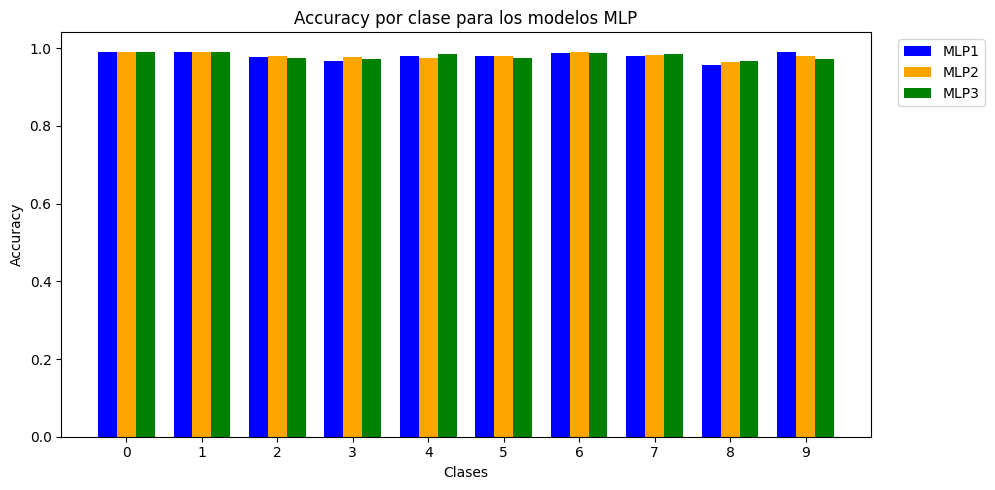


Modelo MLP1:
Mediana 5 iteraciones: 0.9808
Accuracy por clase: [0.99075 0.99125 0.97675 0.967   0.97875 0.97925 0.9865  0.9795  0.9575
 0.989  ]
Accuracy total del modelo: 0.979625


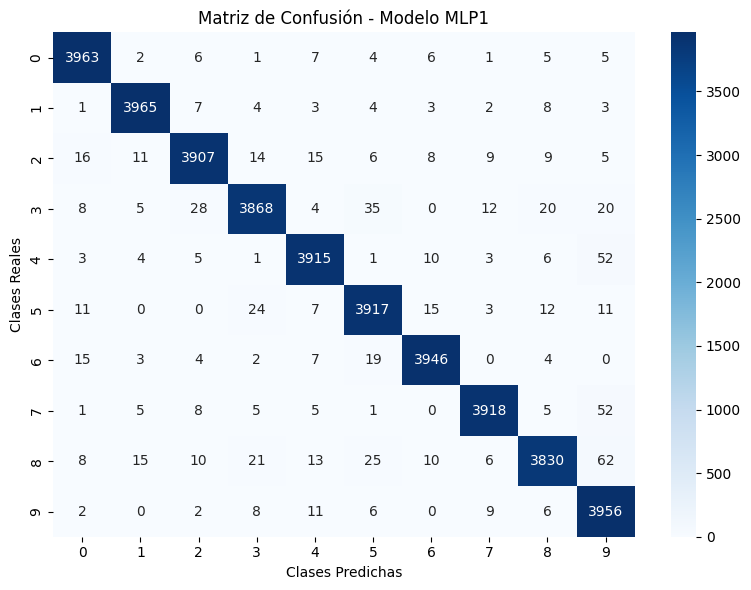


Modelo MLP2:
Mediana 5 iteraciones: 0.9803
Accuracy por clase: [0.99025 0.9895  0.979   0.97625 0.9755  0.97925 0.9895  0.982   0.96375
 0.97875]
Accuracy total del modelo: 0.980375


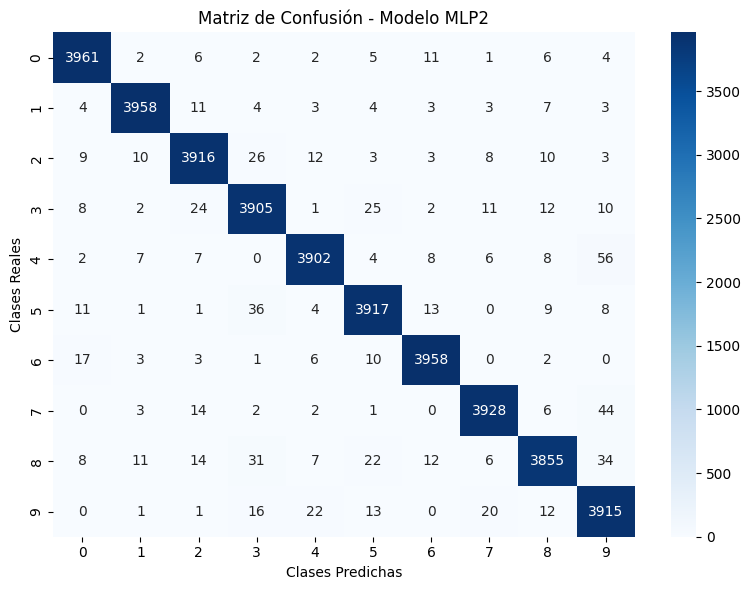


Modelo MLP3:
Mediana 5 iteraciones: 0.9801
Accuracy por clase: [0.98975 0.9905  0.97575 0.97225 0.98475 0.97425 0.987   0.9845  0.968
 0.973  ]
Accuracy total del modelo: 0.979975


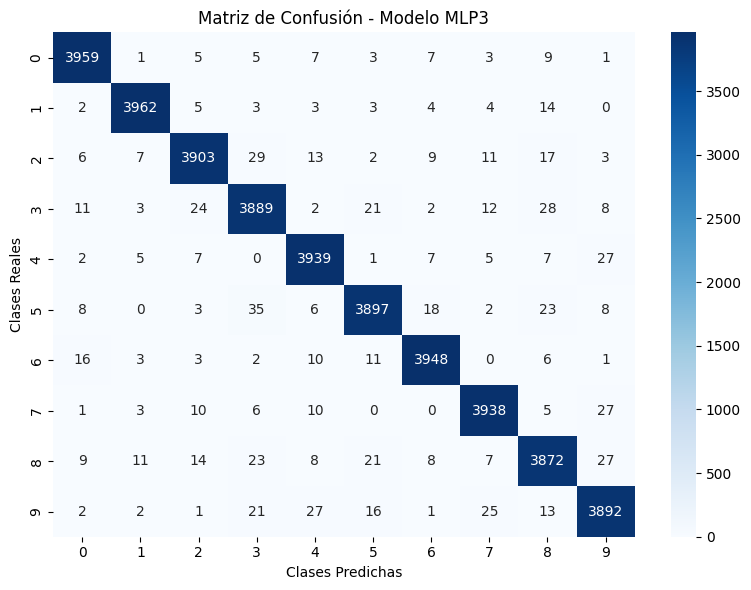


Mediana Diggits: 0.9803


In [16]:
colores = ['blue', 'orange', 'green']
etiquetas = ['MLP1', 'MLP2', 'MLP3']

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.25
x = np.arange(10)

for i, (_, acc_clase, _, _) in enumerate(resultados_1):
    bars = ax.bar(x + i * width, acc_clase, width=width, label=etiquetas[i], color=colores[i])

ax.set_xlabel("Clases")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy por clase para los modelos MLP")
ax.set_xticks(x + width)  
ax.set_xticklabels([str(i) for i in range(10)])  
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1)) 

plt.tight_layout()
plt.show()


mediana_modelo = []
for i, (mediana_acc, acc_clase, matriz_conf, acc_totales) in enumerate(resultados_1):
    # Imprimir otras métricas
    print(f"\nModelo MLP{i + 1}:")
    print(f"Mediana 5 iteraciones: {mediana_acc:.4f}")
    print(f"Accuracy por clase: {acc_clase}")
    print(f"Accuracy total del modelo: {acc_totales}")
    mediana_modelo.append(mediana_acc)
    # Crear un heatmap para la matriz de confusión
    plt.figure(figsize=(8, 6))  # Ajustar tamaño de la figura
    sns.heatmap(
        matriz_conf,
        annot=True,  # Mostrar los valores dentro de las celdas
        fmt="d",  # Formato de los valores (números enteros)
        cmap="Blues",  # Colormap para el heatmap
        cbar=True  # Mostrar barra de color
    )
    plt.title(f"Matriz de Confusión - Modelo MLP{i + 1}")
    plt.xlabel("Clases Predichas")
    plt.ylabel("Clases Reales")
    plt.tight_layout()
    plt.show()

    

print(f"\nMediana Diggits: {np.median(mediana_modelo):.4f}")



Modelo MLP1:
Mediana 5 iteraciones: 0.9906
Accuracy por clase: [0.99175 0.996   0.98475 0.9835  0.9905  0.99175 0.996   0.9935  0.9825
 0.9875 ]


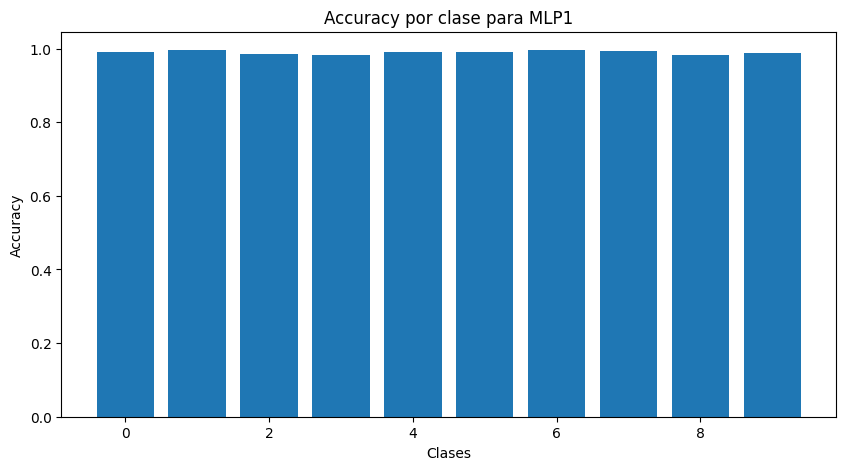

Accuracy total del modelo: 0.989775
Matriz de confusión:
[[3967    1    1    2    4    1   11    1    8    4]
 [   2 3984    3    1    3    2    1    2    2    0]
 [   1    2 3939   16    6    3    1   11   17    4]
 [   4    1    8 3934    0   30    0    4    8   11]
 [   2    4    1    0 3962    0    8    4    4   15]
 [   4    0    0    5    1 3967    7    1    9    6]
 [   5    1    1    0    4    4 3984    0    1    0]
 [   0    1    4    2    6    0    0 3974    1   12]
 [   4    2    1   17    6    7    2    6 3930   25]
 [   3    1    0    3   19    6    0   11    7 3950]]

Modelo MLP2:
Mediana 5 iteraciones: 0.9914
Accuracy por clase: [0.99175 0.9965  0.9925  0.98675 0.988   0.99    0.98925 0.9905  0.992
 0.9895 ]


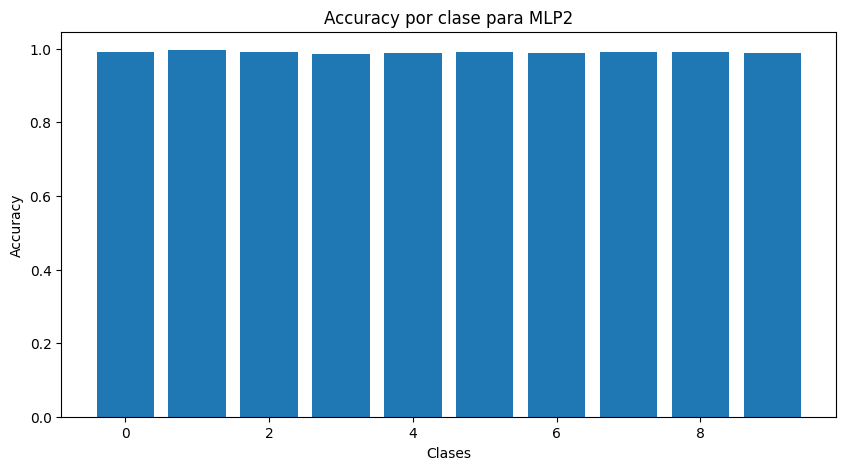

Accuracy total del modelo: 0.990675
Matriz de confusión:
[[3967    2    2    2    3    3    5    0   14    2]
 [   0 3986    3    1    0    2    1    2    4    1]
 [   3    3 3970    6    1    0    0    3   12    2]
 [   2    2    9 3947    0   14    0    4   19    3]
 [   4    3    1    1 3952    2    2    3    9   23]
 [   7    0    0    8    1 3960    4    1   16    3]
 [  10    1    1    0    6    6 3957    0   18    1]
 [   1    2   11    5    3    1    0 3962    5   10]
 [   1    5    3    7    2    6    3    0 3968    5]
 [   0    2    0    3   11    4    0    7   15 3958]]

Modelo MLP3:
Mediana 5 iteraciones: 0.9906
Accuracy por clase: [0.9905  0.9975  0.986   0.987   0.989   0.9905  0.99175 0.99075 0.987
 0.993  ]


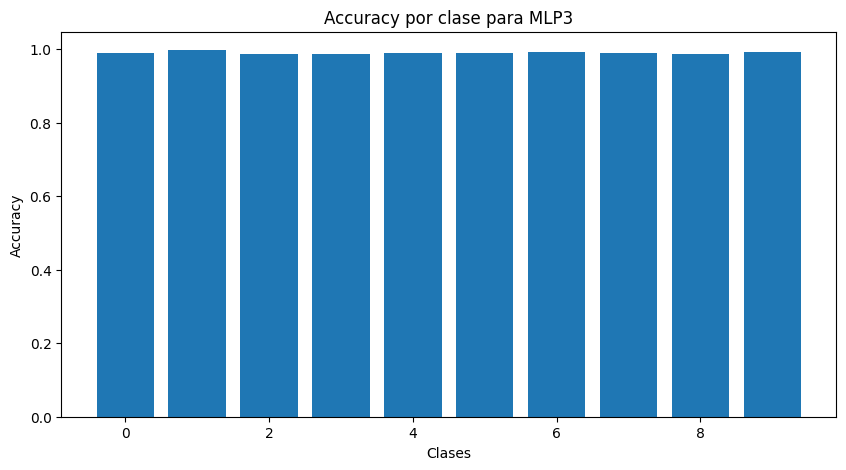

Accuracy total del modelo: 0.9903
Matriz de confusión:
[[3962    1    3    2    2    6   11    0   11    2]
 [   0 3990    1    1    0    2    0    4    2    0]
 [   3    8 3944   10    6    4    2    9   12    2]
 [   1    2    9 3948    0   19    0    6    8    7]
 [   0    3    1    0 3956    0    6    9    3   22]
 [   1    0    0   13    1 3962    7    1   11    4]
 [   6    3    0    0   13    4 3967    0    7    0]
 [   2    3    5    5    2    0    0 3963    2   18]
 [   5    6    3    8    7    5    2    1 3948   15]
 [   0    0    0    2    9    5    0    8    4 3972]]

Mediana Diggits: 0.9906


In [ ]:



'''
# Combinar los resultados de los modelos
resultados_1 = [resultados_MLP1_exp1, resultados_MLP2_exp1, resultados_MLP3_exp1]

# Configuración para los gráficos
colors = ['blue', 'orange', 'green']  # Colores para cada modelo
labels = ['MLP1', 'MLP2', 'MLP3']  # Etiquetas para cada modelo

# Preparar los datos para el gráfico conjunto
fig, ax = plt.subplots(figsize=(10, 5))  # Aumentar el tamaño horizontal del gráfico
width = 0.25  # Ancho de las barras
x = np.arange(10)  # Clases de 0 a 9 (ajustar si hay más clases)

for i, resultados_modelo in enumerate(resultados_1):
    # Extraer accuracy por clase del modelo actual
    _, acc_clase, _, _ = resultados_modelo[0]  # La primera iteración contiene acc_clase
    # Dibujar las barras
    bars = ax.bar(x + i * width, acc_clase, width=width, label=labels[i], color=colors[i])

# Configurar el gráfico
ax.set_xlabel("Clases")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy por clase para los modelos MLP")
ax.set_xticks(x + width)  # Ajustar las posiciones de las etiquetas en el eje X
ax.set_xticklabels([str(i) for i in range(10)])  # Mostrar las clases de 0 a 9
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))  # Mover la leyenda a la derecha, fuera de las barras

plt.tight_layout()
plt.show()

# Métricas por modelo
median_digits = []
for i, resultados_modelo in enumerate(resultados_1):
    mediana_acc, acc_clase, matriz_conf, acc_totales = resultados_modelo[0]  # La primera iteración contiene las métricas finales
    print(f"\nModelo {labels[i]}:")
    print(f"Mediana 5 iteraciones: {mediana_acc:.4f}")
    print(f"Accuracy por clase: {acc_clase}")
    print(f"Accuracy total del modelo: {acc_totales}")
    print(f"Matriz de confusión:")
    print(np.array2string(matriz_conf, max_line_width=np.inf, separator=' '))
    median_digits.append(mediana_acc)

# Mediana general de los modelos
print(f"\nMediana general de los modelos: {np.median(median_digits):.4f}")

'''



<h2>Experimento 2: Subconjunto EMNIST_Letters</h2>

El subconjunto EMNIST_Letters posee 26 clases las cuales representan las letras del abecedario inglés.

A continuación, se cargan los datos necesarios para el entrenamiento y prueba de los modelos

In [28]:
ruta_letters = "./emnist-letters"
# Concatena la ruta de los archivos con la carpeta de las letras con os
ruta_entrenamiento_imagenes = os.path.join(ruta_letters, "emnist-letters-train-images-idx3-ubyte.gz")
ruta_entrenamiento_etiquetas = os.path.join(ruta_letters, "emnist-letters-train-labels-idx1-ubyte.gz")
ruta_prueba_imagenes = os.path.join(ruta_letters, "emnist-letters-test-images-idx3-ubyte.gz")
ruta_prueba_etiquetas = os.path.join(ruta_letters, "emnist-letters-test-labels-idx1-ubyte.gz")
ruta_mapping = os.path.join(ruta_letters, "emnist-letters-mapping.txt")

x_entrenamiento, y_entrenamiento = cargar_datos(ruta_entrenamiento_imagenes, ruta_entrenamiento_etiquetas)
x_prueba, y_prueba = cargar_datos(ruta_prueba_imagenes, ruta_prueba_etiquetas)

mapping = cargar_mapping(ruta_mapping, "letters")


Luego, se muestran de forma aleatoria 20 imágenes tanto para el conjunto de entrenamiento como para el de prueba.

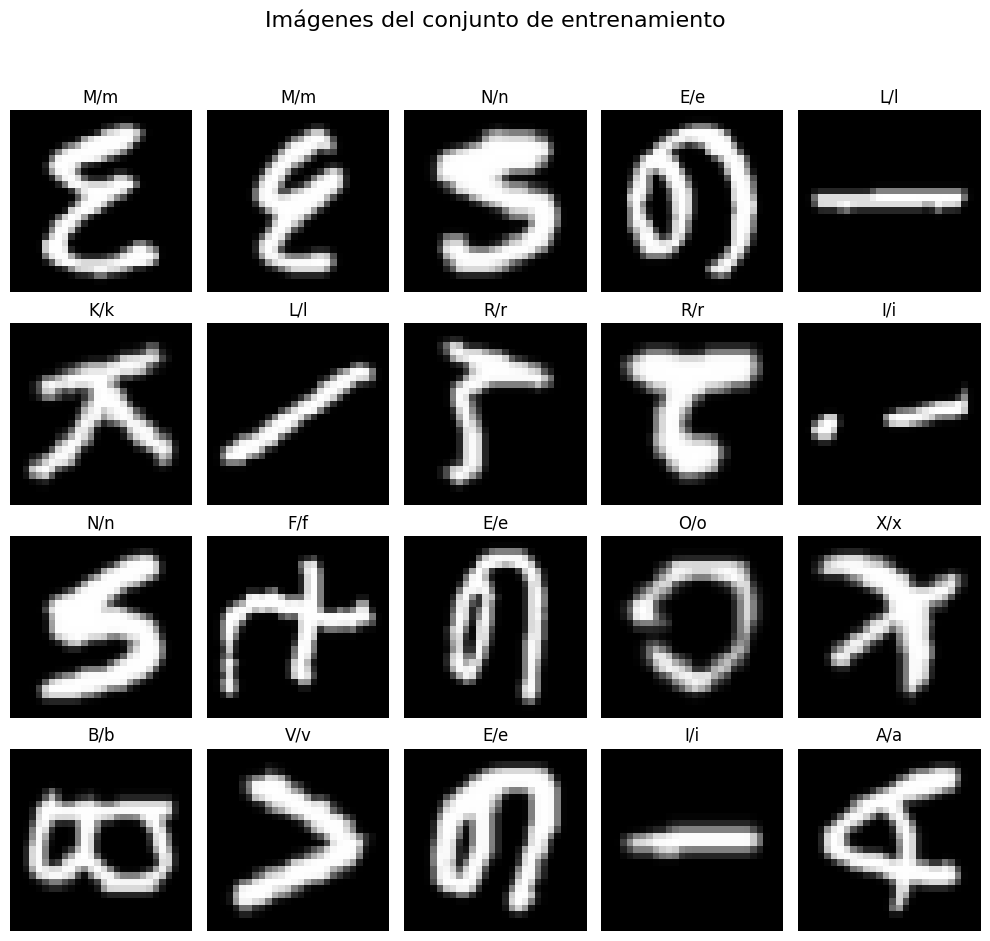

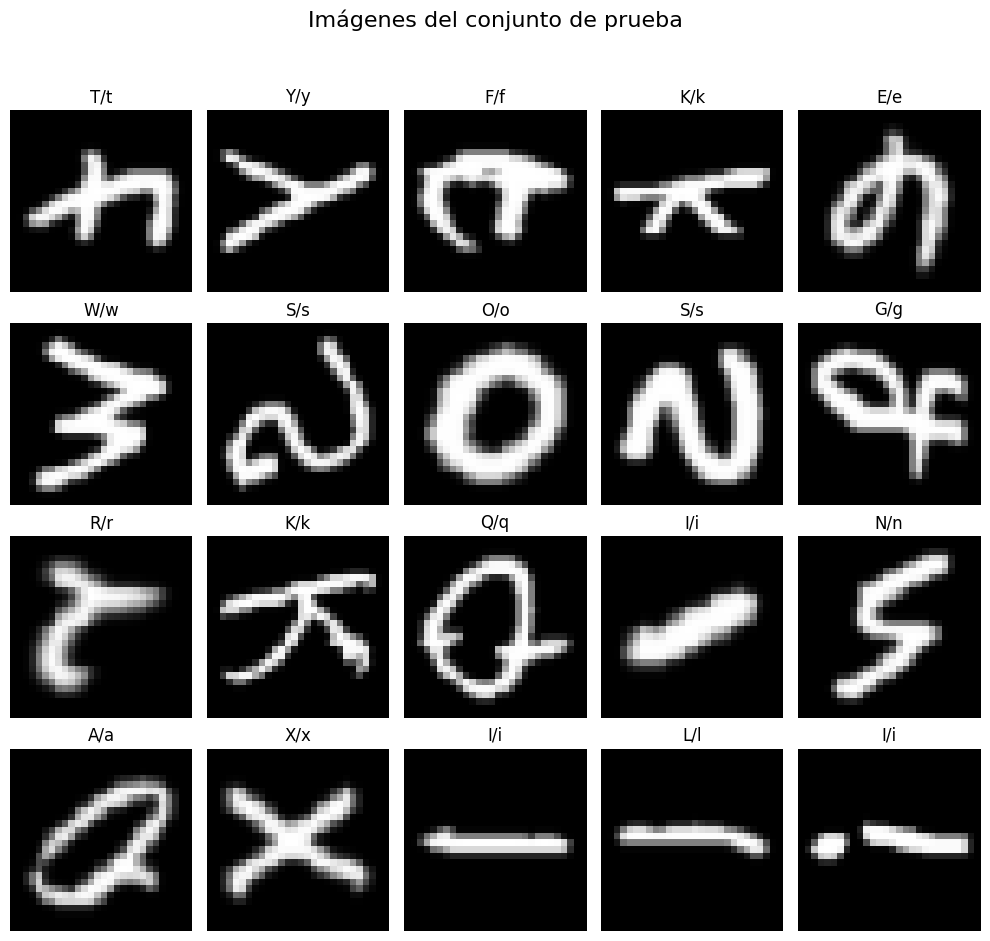

In [29]:
mostrar_imagenes_aleatorias(x_entrenamiento, y_entrenamiento, mapping, cantidad=20, titulo="Imágenes del conjunto de entrenamiento")
mostrar_imagenes_aleatorias(x_prueba, y_prueba, mapping, cantidad=20, titulo="Imágenes del conjunto de prueba")

<h3>Definición y creación de los modelos</h3>

1. Modelo MLP1:
    - Dos capas ocultas con 512 y 256 neuronas respectivamente.
    - Utiliza la función de activación relu.
    - Utiliza la función de pérdida categorical_crossentropy.
    - Utiliza el optimizador Adam con learning rate de 0.0002.
2. Modelo MLP2:
    - Tres capas ocultas con 512, 256 y 128 neuronas respectivamente.
    - Utiliza la función de activación relu.
    - Utiliza la función de pérdida categorical_crossentropy.
    - Utiliza el optimizador Adam con learning rate de 0.0003.
3. Modelo MLP3:
    - Cuatro capas ocultas con 1024, 512, 128 y 64 neuronas respectivamente.
    - Utiliza la función de activación swish.
    - Utiliza la función de pérdida categorical_crossentropy.
    - Utiliza el optimizador Nadam con learning rate de 0.0002.

El siguiente diagrama muestra la configuración por defecto del modelo<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

In [30]:
shape_entrada = (x_entrenamiento.shape[1], )
numero_clases = len(np.unique(y_entrenamiento))

## VER SI ES POR EL ESPACIO EN BLANCO DEL MAPPING<<<<<<<<<<<<<<<<<
y_entrenamiento = y_entrenamiento - 1
y_prueba = y_prueba - 1

y_entrenamiento_categorico = to_categorical(y_entrenamiento, num_classes=numero_clases)
y_prueba_categorico = to_categorical(y_prueba, num_classes=numero_clases)

parametros_mlp1_exp2 = {'capas_ocultas': [512, 256], 'activacion': 'relu', 'loss': 'categorical_crossentropy'}
parametros_mlp2_exp2 = {'capas_ocultas': [512, 256, 128], 'activacion': 'swish', 'loss': 'categorical_crossentropy'}
parametros_mlp3_exp2 = {'capas_ocultas': [1024, 512, 256, 128], 'activacion': 'relu', 'loss': 'sparse_categorical_crossentropy'}

# Creación del modelo MLP1
MLP1_exp2 = crear_modelo(capas_ocultas=parametros_mlp1_exp2['capas_ocultas'], 
                         activacion=parametros_mlp1_exp2['activacion'], 
                         loss=parametros_mlp1_exp2['loss'], 
                         optimizador=Adam(learning_rate=0.0002), 
                         entradas=shape_entrada, 
                         salidas=numero_clases)

# Creación del modelo MLP2
MLP2_exp2 = crear_modelo(capas_ocultas=parametros_mlp2_exp2['capas_ocultas'], 
                         activacion=parametros_mlp2_exp2['activacion'], 
                         loss=parametros_mlp2_exp2['loss'], 
                         optimizador=Adam(learning_rate=0.0003), 
                         entradas=shape_entrada, 
                         salidas=numero_clases)

# Creación del modelo MLP3
MLP3_exp2 = crear_modelo(capas_ocultas=parametros_mlp3_exp2['capas_ocultas'], 
                         activacion=parametros_mlp3_exp2['activacion'], 
                         loss=parametros_mlp3_exp2['loss'], 
                         optimizador=Nadam(learning_rate=0.0002), 
                         entradas=shape_entrada, 
                         salidas=numero_clases)

<h3>Entrenamiento y prueba del subconjunto EMNIST_Letters </h3>

In [31]:
resultados = entrenar_y_evaluar_modelos([MLP1_exp2, MLP2_exp2, MLP3_exp2], x_entrenamiento, y_entrenamiento, x_prueba, y_prueba, numero_clases)

Entrenando Modelo MLP1...
  Repetición 1...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 2...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 3...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 4...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
  Repetición 5...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step
Entrenando Modelo MLP2...
  Repetición 1...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 2...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 3...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 4...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Repetición 5...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Entrenando Modelo MLP3...
  Repetición 1...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Repetición 2...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Repetición 3...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Repetición 4...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Repetición 5...
650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<h3>Resultados</h3>

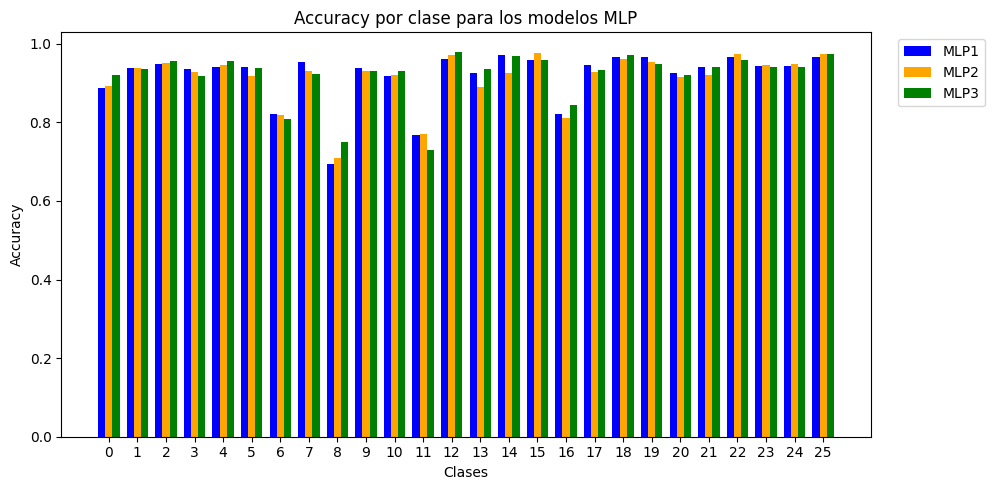


Modelo MLP1:
Mediana 5 iteraciones: 0.9178
Accuracy por clase: [0.88625 0.93875 0.94875 0.93625 0.94    0.94125 0.82125 0.95375 0.69375
 0.9375  0.9175  0.76875 0.96    0.925   0.97125 0.9575  0.82    0.945
 0.96625 0.965   0.92625 0.94    0.9675  0.9425  0.9425  0.96625]
Accuracy total del modelo: 0.9184134615384615
Matriz de confusión:
[[709   1   6   7   6   0  15   6   1   0   0   0   2   6   4   2  17   3   0   2   3   0   3   2   1   4]
 [  3 751   0   4   8   0   5  14   0   1   1   3   0   1   3   0   1   1   0   0   0   0   0   0   0   4]
 [  0   1 759   1  11   1   2   0   0   0   0   5   0   0   6   1   0   5   3   2   1   0   1   0   0   1]
 [  3   1   0 749   0   1   0   1   1   3   0   0   1   2  26   2   2   1   3   0   3   0   1   0   0   0]
 [  1   2  19   0 752   3   2   1   2   0   0   2   0   0   3   3   1   3   1   3   1   1   0   0   0   0]
 [  1   0   0   1   2 753   2   0   1   1   0   1   0   0   0   7   0   8   4  19   0   0   0   0   0   0]
 [ 13   8   3   1

In [ ]:
# Suponiendo que `resultados` contiene las métricas de cada modelo
colors = ['blue', 'orange', 'green']  # Colores para cada modelo
labels = ['MLP1', 'MLP2', 'MLP3']  # Etiquetas para cada modelo

# Preparar los datos para el gráfico conjunto
fig, ax = plt.subplots(figsize=(10, 5))  # Aumentar el tamaño horizontal del gráfico
width = 0.25  # Ancho de las barras
x = np.arange(26)  # Clases de 0 a 25

for i, (_, acc_clase, _, _) in enumerate(resultados):
    # Dibujar las barras
    bars = ax.bar(x + i * width, acc_clase, width=width, label=labels[i], color=colors[i])

# Configurar el gráfico
ax.set_xlabel("Clases")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy por clase para los modelos MLP")
ax.set_xticks(x + width)  # Ajustar las posiciones de las etiquetas en el eje X
ax.set_xticklabels([str(i) for i in range(26)])  # Mostrar las clases de 0 a 25
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))  # Mover la leyenda a la derecha, fuera de las barras

plt.tight_layout()
plt.show()

median_letters = []
for i, (mediana_acc, acc_clase, matriz_conf, acc_totales) in enumerate(resultados):
    print(f"\nModelo MLP{i + 1}:")
    print(f"Mediana 5 iteraciones: {mediana_acc:.4f}")
    print(f"Accuracy por clase: {acc_clase}")
    print(f"Accuracy total del modelo: {acc_totales}")
    print(f"Matriz de confusión:")
    print(np.array2string(matriz_conf, max_line_width=np.inf, separator=' '))
    median_letters.append(mediana_acc)

print(f"\nMediana Letters: {np.median(median_letters):.4f}")



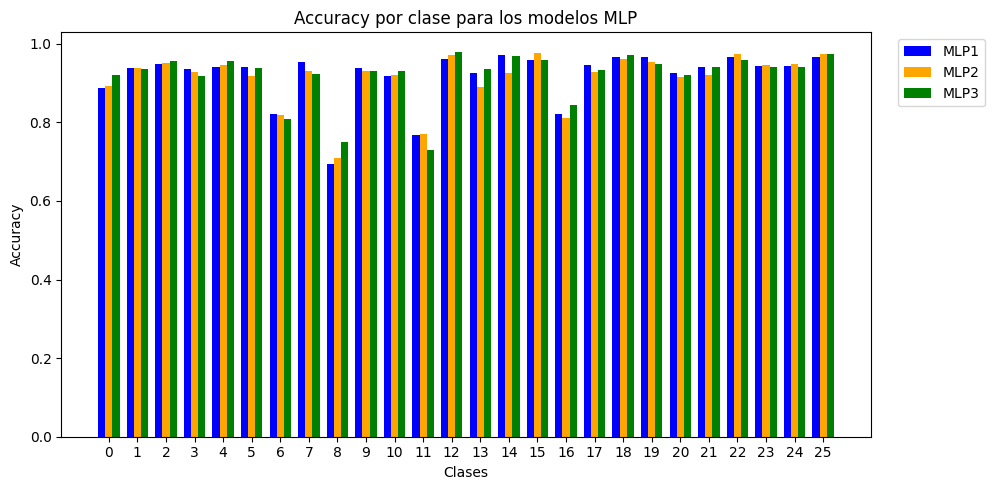


Modelo MLP1:
Mediana 5 iteraciones: 0.9178

Accuracy por clase:
   Clase  Accuracy
0      0   0.88625
1      1   0.93875
2      2   0.94875
3      3   0.93625
4      4   0.94000
5      5   0.94125
6      6   0.82125
7      7   0.95375
8      8   0.69375
9      9   0.93750
10    10   0.91750
11    11   0.76875
12    12   0.96000
13    13   0.92500
14    14   0.97125
15    15   0.95750
16    16   0.82000
17    17   0.94500
18    18   0.96625
19    19   0.96500
20    20   0.92625
21    21   0.94000
22    22   0.96750
23    23   0.94250
24    24   0.94250
25    25   0.96625

Matriz de confusión:
          Clase 0  Clase 1  Clase 2  Clase 3  Clase 4  Clase 5  Clase 6  \
Clase 0       709        1        6        7        6        0       15   
Clase 1         3      751        0        4        8        0        5   
Clase 2         0        1      759        1       11        1        2   
Clase 3         3        1        0      749        0        1        0   
Clase 4         1        

In [50]:

# Suponiendo que `resultados` contiene las métricas de cada modelo
colors = ['blue', 'orange', 'green']  # Colores para cada modelo
labels = ['MLP1', 'MLP2', 'MLP3']  # Etiquetas para cada modelo

# Preparar los datos para el gráfico conjunto
fig, ax = plt.subplots(figsize=(10, 5))  # Aumentar el tamaño horizontal del gráfico
width = 0.25  # Ancho de las barras
x = np.arange(26)  # Clases de 0 a 25

# Crear gráfico conjunto
for i, (_, acc_clase, _, _) in enumerate(resultados):
    bars = ax.bar(x + i * width, acc_clase, width=width, label=labels[i], color=colors[i])

# Configurar el gráfico
ax.set_xlabel("Clases")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy por clase para los modelos MLP")
ax.set_xticks(x + width)
ax.set_xticklabels([str(i) for i in range(26)])
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

# Mostrar las métricas individuales para cada modelo
median_letters = []

for i, (mediana_acc, acc_clase, matriz_conf, acc_totales) in enumerate(resultados):
    print(f"\nModelo MLP{i + 1}:")
    print(f"Mediana 5 iteraciones: {mediana_acc:.4f}")

    # Mostrar Accuracy por clase como tabla
    acc_table = pd.DataFrame({
        'Clase': [str(j) for j in range(len(acc_clase))],
        'Accuracy': acc_clase
    })
    print("\nAccuracy por clase:")
    print(acc_table)

    # Mostrar matriz de confusión como tabla
    conf_table = pd.DataFrame(matriz_conf, columns=[f"Clase {j}" for j in range(matriz_conf.shape[1])])
    conf_table.index = [f"Clase {j}" for j in range(matriz_conf.shape[0])]

    print("\nMatriz de confusión:")
    print(conf_table)

    # Agregar a las medianas
    median_letters.append(mediana_acc)

print(f"\nMediana Diggits: {np.median(median_letters):.4f}")
